Optical Flow?
-  연속된 두 프레임 사이에서 픽셀이 어디로 움직였는지 계산
- 물체 속도 방향
- 자율주행, 드론, 동작인식

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow # Colab 환경에서 이미지 표시를 위한 함수 임포트
import time # 출력 속도를 조절하기 위한 time 모듈 임포트

video_path = '/content/drive/MyDrive/CV_work/AI_응용_강의자료/data/bird.mp4'

In [33]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print('Error opening video file')
    exit



In [34]:
# 프레임 재생 속도 조절 1000ms/30fps = 33ms
delay = int(1000/30)

# 추적 경로를 그리기 위한 랜덤 색상 (200개 코너 점에 대응 하는 색상)
# 0~255사이에서 3채널 색상 200개 생성.
color = np.random.randint(0,255,(200,3))

lines = None # 추적선 (이동경로) 초기화
previmg = None # 이전 프레임 초기



termcriteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10 , 0.03)


frame_count = 0
MAX_FRAMES_TO_PROCESS = 150
DISPLAY_EVERY_N_FRAMES = 20


print(f"광학 흐름 추적 시작 (최대 {MAX_FRAMES_TO_PROCESS} 프레임, {DISPLAY_EVERY_N_FRAMES} 프레임마다 출력)...")

광학 흐름 추적 시작 (최대 150 프레임, 20 프레임마다 출력)...


In [ ]:
# 예제
'''
p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, gray, p0, None,
                                      winSize=(15,15),
                                      maxLevel=2,
                                      criteria=termcriteria)

cv2.calcOpticalFlowPyrLK (루카스-카나데 광학 흐름) 물체 이동 위치를 추적
old_gray, gray (grayscale한 이미지) 이전 사진, 현재 사진
p0 : position 추적하고 싶은 점들의 좌표
None :  기본 설정
winSize=(15,15) 추적한 윈도우 사이즈 (주변 15*15 영역 비교 이동방향 계산)
maxLevel=2 이미지 피라미드 레벨 (영상 축소 단계 수)
criteria=termcriteria : 우리가 설정한 정지조건(기준) (최대 10번 또는 오차 0.03 미만)

p1: 추적된 새로운 좌표값 (position)
st: 추적 성공 여부 (1: 성공, 0: 실패) status
err: 추적 오류 (오차 정도) error

p0 (100, 200) 서있는 상태
p1 (50, 100)  오리걸음 하는 상태

st = 1 # 성공 (잘 추적했네)
err = 0.01 # 오차 거의 없네 (기준인 0.03 미만이니깐)
'''

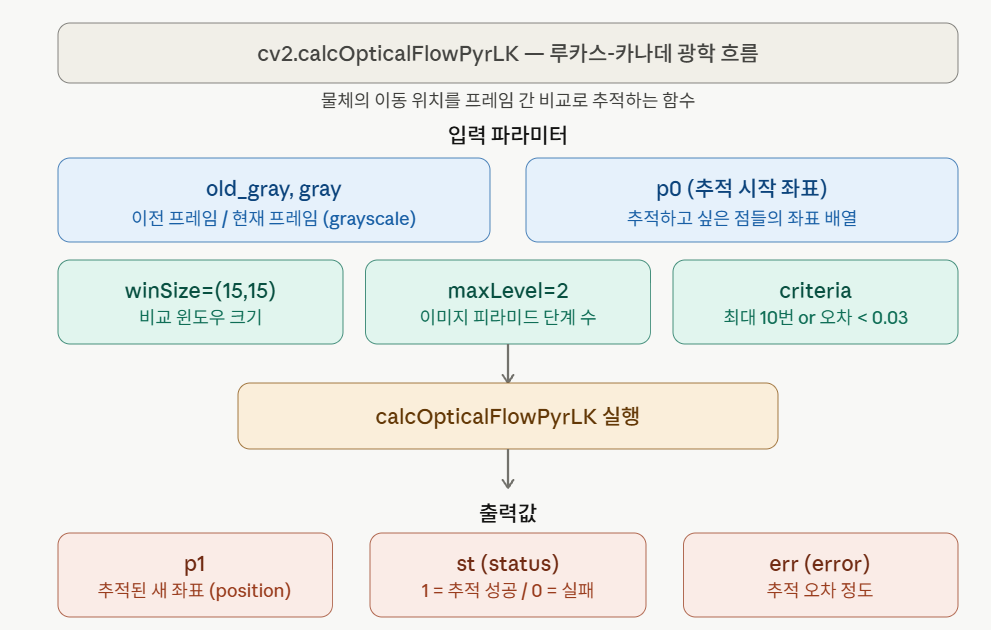

In [35]:
# 비디오 처리
while cap.isOpened() and frame_count < MAX_FRAMES_TO_PROCESS:
    ret, frame = cap.read()

    if not ret:
        break


    img_draw  =frame.copy()

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 최초 프레임 시작 : 여기서 부터 조금 달라진대ㅛㅇ

    if previmg is None :
        previmg = gray
        lines = np.zeros_like(frame) # 추적선 그릴 검은 배경이미지
        prevPt = cv2.goodFeaturesToTrack(previmg,30,0.01,10) # 코너 검출 알고리즘
        # 이전 이미지, 추적 갯수, 품질임계값, 코너간 최소 거리
    else: # 두번째 프레임부터
        nextimg= gray

        nextPt,status, err = cv2.calcOpticalFlowPyrLK(previmg, nextimg,
                                                       prevPt, None, criteria = termcriteria)


        # status == 1은 추적에 성공한 코너점
        prevMv = prevPt[status == 1] # 이전 프레임에서 추적 성공한 점
        nextMv = nextPt[status == 1] # 현재 프레임에서 추적 성공한 점

        # 추적 성공한 모든 쌍에 대해서 반복
        for i, (p, n) in enumerate(zip(prevMv, nextMv)):
            # 코너점 좌표 추출(배열 구조 해제)
            # 왜 하는 거야? (귀찮은 듯)
            # >> OpenCV 때문이야 [[130, 85]] >> [130, 85]
            px, py = p.ravel() # raval은 평탄화하는거야. 위에 있는 설명이 이거네.
            nx, ny = n.ravel()

            # 이전 코너(p)와 새로운 코너(n) 사이에 추적선 그리기(lines 이미지에 누적)
            cv2.line(lines, (int(px), int(py)), (int(nx), int(ny)), color[i % len(color)].tolist(), 2)
            # 시작점 : 이전 위치(px,py) 끝점 (nx,ny)
            # color[i%len(color)].tolist() 코너점 i에 할당된 랜덤 색.

            # 새로운 코너에 d원형 점 그리기
            cv2.circle(img_draw,(int(nx),int(ny)),2,color[i%len(color)].tolist(),-1)

        #누적된 추적선이 그려진 lines이미지와 현재 프레임 생성
        # 추적 경로가 비디오 프레임 위에 나타남.
        img_draw = cv2.add(img_draw, lines)

        # 다음 루프 위해서 현제 프레임(사진)과 코너점 -> 이전값으로 변경

        previmg = nextimg
        prevPt = nextMv.reshape(-1,1,2)
        # prevPt를 nextMv형태로 맞춰줘야 함
        # (N,2) -> (N,1,2)
        # -1 : 자동계산
        # 2 : x,y 좌표


        # 원래 좌표 형식 [[x,y],[x,y],[x,y]]  shape (3,2) >>> (N,2)
        # OpenCV optical Flow 함수 입력 [[[x,y]],[[x,y]],[[x,y]]] shape (3,1,2) >> (N, 1, 2)
        # >> OpenCV 컨투어(윤과선) 기본적으로 (점의 개수, 1, 2)
        # >> 기본적 [행, 열, 채널] [N(데이터 개수), 1(열: 점 하나 하나(개별 데이터), 2(채널, 좌표 x,y))]


    # Colab 출력: 특정 간격의 프레임만 표시
    if frame_count % DISPLAY_EVERY_N_FRAMES == 0:
        print(f"\n--- Frame {frame_count} 광학 흐름 결과 ---")
        cv2_imshow(img_draw) # 추적 결과 프레임 표시
        time.sleep(1) # 출력이 빠르게 지나가는 것을 방지하기 위해 잠시 대기


    frame_count +=1

cap.release()



Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# eos